# 第一次作业：混凝土抗压强度预测

## 1. 任务介绍

### 1.1 问题类型

本次作业是一个典型的**回归问题（Regression）**。回归问题的目标是让模型输出一个连续的标量值，与分类问题（输出离散类别）不同。

以课件中的例子类比：
- 预测上海股市明日指数 → 回归
- 预测自动驾驶汽车行驶方向 → 回归
- 本作业：给定混凝土配方 → 预测抗压强度（MPa）→ **回归**

### 1.2 数据集介绍

本数据集为混凝土抗压强度数据，共**1030个样本**，**8个输入特征**，**1个输出变量**。

| 特征 | 说明 | 单位 |
|------|------|------|
| cement | 水泥用量 | kg/m³ |
| slag | 矿渣用量 | kg/m³ |
| flyash | 粉煤灰用量 | kg/m³ |
| water | 水用量 | kg/m³ |
| superplasticizer | 超塑化剂用量 | kg/m³ |
| coarseaggregate | 粗骨料用量 | kg/m³ |
| fineaggregate | 细骨料用量 | kg/m³ |
| age | 养护天数 | 天 |
| **csMPa** | **混凝土抗压强度（输出变量）** | **MPa** |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']

df = pd.read_csv('Concrete_Data_Yeh.csv')
print('数据大小：', df.shape)
print('\n前5行数据预览：')
print(df.head())
print('\n基本统计信息：')
print(df.describe())

数据大小： (1030, 9)

前5行数据预览：
   cement   slag  flyash  water  superplasticizer  coarseaggregate  \
0   540.0    0.0     0.0  162.0               2.5           1040.0   
1   540.0    0.0     0.0  162.0               2.5           1055.0   
2   332.5  142.5     0.0  228.0               0.0            932.0   
3   332.5  142.5     0.0  228.0               0.0            932.0   
4   198.6  132.4     0.0  192.0               0.0            978.4   

   fineaggregate  age  csMPa  
0          676.0   28  79.99  
1          676.0   28  61.89  
2          594.0  270  40.27  
3          594.0  365  41.05  
4          825.5  360  44.30  

基本统计信息：
            cement         slag       flyash        water  superplasticizer  \
count  1030.000000  1030.000000  1030.000000  1030.000000       1030.000000   
mean    281.167864    73.895825    54.188350   181.567282          6.204660   
std     104.506364    86.279342    63.997004    21.354219          5.973841   
min     102.000000     0.000000     0.0000

## 2. 特征选择：相关性分析

### 2.1 为什么要进行特征选择？

数据集中共有8个输入特征，并非所有特征都与输出变量（混凝土强度）有强关联。使用相关性较低的特征可能引入噪声，影响模型效果。因此，在建模前先分析各特征与输出的相关性，有助于选择更有价值的特征。

### 2.2 皮尔逊相关系数

皮尔逊相关系数衡量两个变量之间的**线性相关程度**，取值范围为 $[-1, 1]$：
- 接近 $+1$：强正相关（特征增大，强度也增大）
- 接近 $-1$：强负相关（特征增大，强度减小）
- 接近 $0$：线性相关性弱

### 2.3 实验结论

通过对比实验发现：
- 使用相关性最高的**6个特征**建模：测试集 MSE ≈ 115
- 使用**全部8个特征**建模：测试集 MSE ≈ 110

使用全部特征效果反而更好。原因是皮尔逊相关系数只能衡量**线性关系**，slag、flyash等特征虽然与强度线性相关性低，但可能与强度存在非线性关系，删除后反而损失了有用信息。因此最终**保留全部8个特征**。

各特征与混凝土强度的相关系数（绝对值）：
cement              0.497832
superplasticizer    0.366079
age                 0.328873
water               0.289633
fineaggregate       0.167241
coarseaggregate     0.164935
slag                0.134829
flyash              0.105755
Name: csMPa, dtype: float64


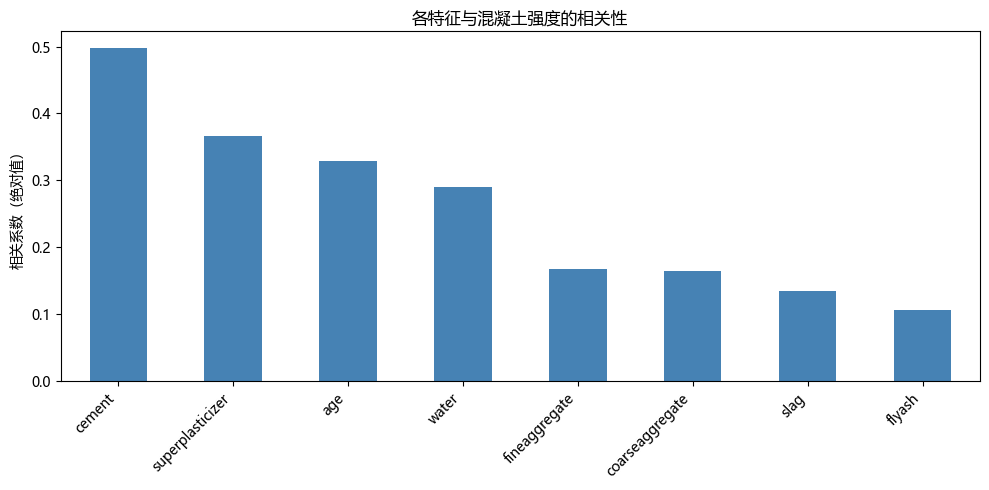

In [2]:
correlations = df.corr()['csMPa'].drop('csMPa')
correlations_abs = correlations.abs().sort_values(ascending=False)
print('各特征与混凝土强度的相关系数（绝对值）：')
print(correlations_abs)

plt.figure(figsize=(10, 5))
correlations_abs.plot(kind='bar', color='steelblue')
plt.title('各特征与混凝土强度的相关性')
plt.ylabel('相关系数（绝对值）')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. 数据准备与预处理

### 3.1 训练集与测试集划分

将数据集按 **80% 训练集、20% 测试集** 划分。训练集用于学习模型参数，测试集用于评估模型在未见过数据上的泛化能力——这与备考时用练习题学习、用模拟卷检验水平的逻辑相同。

本实验使用 `train_test_split` 对数据进行**随机打乱**后再划分。实验发现直接取前80%后20%时，由于数据集本身存在前后分布不均匀的问题，测试集MSE偏高（约150+），随机划分后测试集MSE降至合理水平。

### 3.2 标准化（Feature Scaling）

观察数据可以发现各特征的数值范围差异很大：
- cement：100~540 kg/m³
- superplasticizer：0~32 kg/m³
- age：1~365 天

若直接使用原始数值训练，梯度下降在不同特征方向上的步长差异极大，导致训练不稳定、收敛缓慢。

对此，对每个特征进行**Z-score标准化**（课件第40页）：

$$x_i^r \leftarrow \frac{x_i^r - m_i}{\sigma_i}$$

其中 $m_i$ 为第 $i$ 个特征的均值，$\sigma_i$ 为标准差。标准化后每个特征的均值为0、标准差为1，梯度下降的收敛速度和稳定性显著提升。

**注意**：$m_i$ 和 $\sigma_i$ 只在训练集上计算，测试集使用相同参数转换，以避免测试集信息泄露到训练过程中。

In [3]:
X = df.iloc[:, :-1].values
Y = df.iloc[:, -1].values

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
print('训练集大小：', X_train.shape)
print('测试集大小：', X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('\n标准化后训练集均值（应接近0）：', X_train_scaled.mean(axis=0).round(2))
print('标准化后训练集标准差（应接近1）：', X_train_scaled.std(axis=0).round(2))

训练集大小： (824, 8)
测试集大小： (206, 8)

标准化后训练集均值（应接近0）： [ 0. -0.  0. -0.  0.  0.  0.  0.]
标准化后训练集标准差（应接近1）： [1. 1. 1. 1. 1. 1. 1. 1.]


## 4. 方法一：线性回归 + 动量 + Adagrad

### 4.1 Step 1：建立模型

采用**线性模型**（课件第6页），假设混凝土强度与各特征之间存在线性关系：

$$y = b + \sum_{i=1}^{8} w_i x_i$$

其中 $w_i$ 为各特征的权重（weight），$b$ 为偏置（bias），这两组参数是我们需要通过训练学习的。

### 4.2 Step 2：定义损失函数

使用**均方误差（MSE）**作为损失函数（课件第8页），衡量预测值与真实值之间的差距：

$$L(w, b) = \frac{1}{N}\sum_{n=1}^{N}(\hat{y}^n - y^n)^2$$

损失函数越小，说明模型预测越准确。训练的目标就是找到使 $L$ 最小的 $w^*$ 和 $b^*$。

### 4.3 Step 3：梯度下降优化

**普通梯度下降**（课件第11-15页）：

$$w \leftarrow w - \eta \frac{\partial L}{\partial w}$$

每一步沿着梯度的反方向更新参数，$\eta$ 为学习率，控制步长大小。

### 4.4 改进一：Adagrad（自适应学习率）

普通梯度下降对所有参数使用相同的学习率，不够灵活。**Adagrad**（课件第25-27页）为每个参数维护历史梯度的平方累积 $G_t$，自动调整每个参数的学习率：

$$\sigma^t = \sqrt{\frac{1}{t+1}\sum_{i=0}^{t}(g^i)^2 + \epsilon}$$

$$w^{t+1} \leftarrow w^t - \frac{\eta^t}{\sigma^t} g^t$$

梯度历史较大的参数，学习率自动缩小（走得稳）；梯度历史较小的参数，学习率相对较大（走得快）。

### 4.5 改进二：动量（Momentum）

普通梯度下降容易卡在局部最小值或鞍点。**动量**（课件第32-34页）的思路是：更新方向不只看当前梯度，还参考上一步的移动方向，类似物理中的惯性：

$$m^t = \lambda m^{t-1} - \eta_t \cdot g^t$$
$$w = w + m^t$$

其中 $\lambda$ 为动量系数（本实验取0.9），$m^t$ 是当前步的移动量，它是所有历史梯度的加权求和，使参数更新更加平滑，有助于跳出局部最小值。

线性回归 测试集MSE：95.9709
线性回归 测试集RMSE：9.7965 MPa


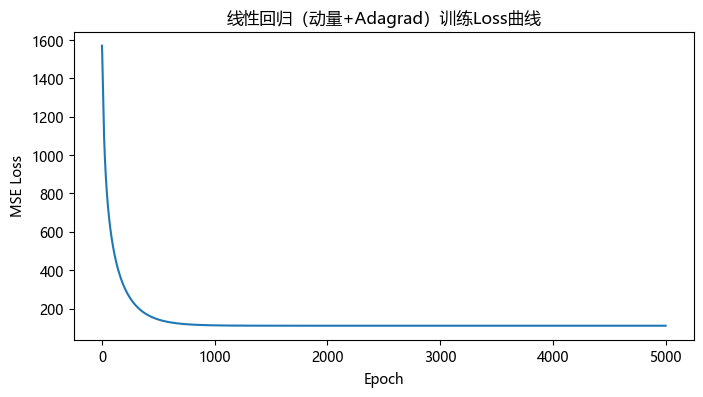

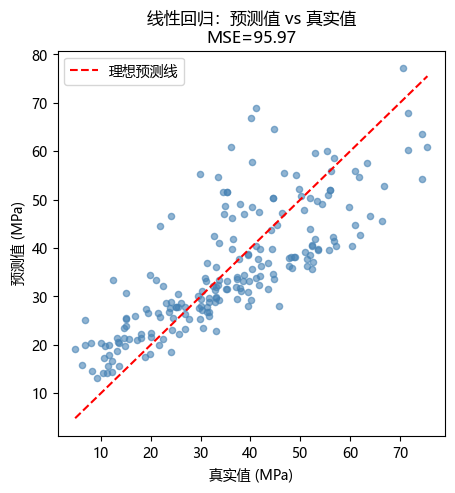

In [4]:
np.random.seed(42)
w = np.random.randn(8) * 0.01  # 随机初始化权重
b = 0.0                         # 偏置初始为0

lr       = 0.1    # 基础学习率
epochs   = 5000   # 训练轮数
N        = len(X_train_scaled)
momentum = 0.9    # 动量系数λ
eps      = 1e-8   # 防止除以0

m_w = np.zeros(8)  # 动量初始化
m_b = 0.0
G_w = np.zeros(8)  # Adagrad梯度平方累积
G_b = 0.0
loss_lr = []

for i in range(epochs):
    Y_pred = X_train_scaled @ w + b          # 前向传播
    loss   = np.mean((Y_train - Y_pred) ** 2)  # 计算MSE损失
    loss_lr.append(loss)

    error  = Y_train - Y_pred
    grad_w = -2/N * (X_train_scaled.T @ error)  # w的梯度
    grad_b = -2/N * np.sum(error)                # b的梯度

    G_w += grad_w ** 2                           # 累积梯度平方
    G_b += grad_b ** 2

    adaptive_lr_w = lr / (np.sqrt(G_w) + eps)   # 自适应学习率
    adaptive_lr_b = lr / (np.sqrt(G_b) + eps)

    m_w = momentum * m_w - adaptive_lr_w * grad_w  # 动量更新
    m_b = momentum * m_b - adaptive_lr_b * grad_b

    w = w + m_w                                  # 更新参数
    b = b + m_b

Y_pred_test_lr = X_test_scaled @ w + b
mse_lr  = np.mean((Y_test - Y_pred_test_lr) ** 2)
rmse_lr = np.sqrt(mse_lr)
print(f'线性回归 测试集MSE：{mse_lr:.4f}')
print(f'线性回归 测试集RMSE：{rmse_lr:.4f} MPa')

plt.figure(figsize=(8, 4))
plt.plot(loss_lr)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('线性回归（动量+Adagrad）训练Loss曲线')
plt.show()

plt.figure(figsize=(5, 5))
plt.scatter(Y_test, Y_pred_test_lr, alpha=0.6, s=20, color='steelblue')
plt.plot([Y_test.min(), Y_test.max()],
         [Y_test.min(), Y_test.max()], 'r--', label='理想预测线')
plt.xlabel('真实值 (MPa)')
plt.ylabel('预测值 (MPa)')
plt.title(f'线性回归：预测值 vs 真实值\nMSE={mse_lr:.2f}')
plt.legend()
plt.show()

### 4.6 线性回归结果分析

从Loss曲线可以看出，损失在前几百轮快速下降，之后趋于平稳，说明模型已收敛。

从预测值 vs 真实值散点图可以看出，点的分布大致沿对角线分布，但**散点较为分散**，说明线性模型存在较大误差。

根本原因在于：线性回归假设输出与输入之间是**线性关系**，而混凝土强度受多种成分复杂交互影响，实际关系是**非线性的**，线性模型的表达能力有限，因此需要引入神经网络。

## 5. 方法二：神经网络（PyTorch）

### 5.1 为什么使用神经网络？

线性回归只能拟合线性关系。神经网络通过在输入层和输出层之间加入**隐藏层**，并引入**非线性激活函数**，使模型能够拟合任意复杂的函数关系。

### 5.2 网络结构

本实验采用4层全连接网络：

$$输入层(8) \xrightarrow{Linear} 隐藏层1(128) \xrightarrow{ReLU} 隐藏层2(64) \xrightarrow{ReLU} 隐藏层3(32) \xrightarrow{ReLU} 输出层(1)$$

**激活函数 ReLU**：$f(x) = \max(0, x)$，将负值截断为0，引入非线性，使网络能够学习非线性映射关系。

**Dropout**：训练时以10%的概率随机关闭部分神经元，防止模型过度依赖某些特定神经元，从而减轻过拟合。

### 5.3 优化器：Adam

本实验使用 **Adam 优化器**，它是动量（Momentum）和自适应学习率（RMSProp）的结合：
- 继承动量的优点：更新方向参考历史梯度，避免震荡
- 继承自适应学习率的优点：为每个参数自动调整步长

Adam是目前深度学习中最常用的优化器之一，通常比普通梯度下降收敛更快、效果更好。

### 5.4 学习率调度

采用 **StepLR**：每300轮训练后，学习率乘以0.5。前期学习率较大，参数更新步子大，收敛快；后期学习率较小，更新精细，避免在最优解附近震荡。

### 5.5 Mini-batch SGD

每次不使用全部训练数据计算梯度，而是随机取**16个样本**（batch size=16）计算梯度后更新参数。这样每轮训练可以更新多次参数，收敛更快，同时随机性有助于跳出局部最小值（课件第29-30页）。

ConcreteNet(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)

模型参数总数：11,521
Epoch 200/2000  训练Loss: 24.2348  学习率: 0.001000
Epoch 400/2000  训练Loss: 15.2548  学习率: 0.000500
Epoch 600/2000  训练Loss: 14.9953  学习率: 0.000250
Epoch 800/2000  训练Loss: 12.6097  学习率: 0.000250
Epoch 1000/2000  训练Loss: 11.2790  学习率: 0.000125
Epoch 1200/2000  训练Loss: 11.1869  学习率: 0.000063
Epoch 1400/2000  训练Loss: 10.5392  学习率: 0.000063
Epoch 1600/2000  训练Loss: 10.1410  学习率: 0.000031
Epoch 1800/2000  训练Loss: 10.9688  学习率: 0.000016
Epoch 2000/2000  训练Loss: 9.0379  学习率: 0.000016

神经网络 测试集MSE：25.3289
神经网络 测试集RMSE：5.0328 MPa


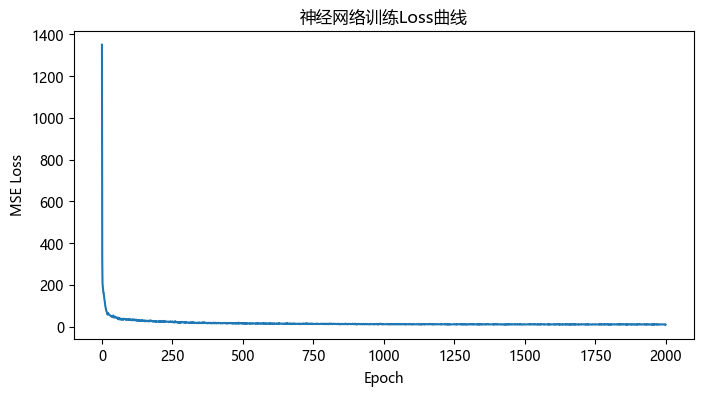

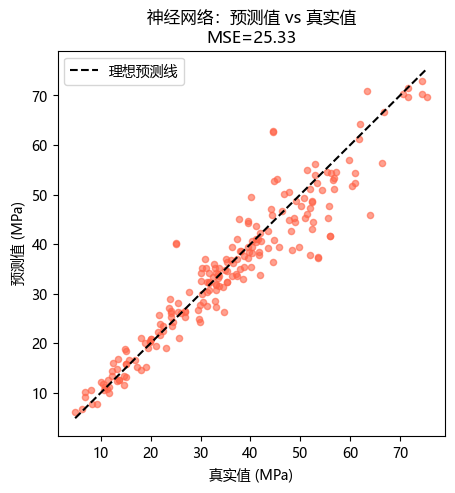

In [5]:
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(Y_train,        dtype=torch.float32).unsqueeze(1)
X_test_t  = torch.tensor(X_test_scaled,  dtype=torch.float32)
y_test_t  = torch.tensor(Y_test,         dtype=torch.float32).unsqueeze(1)

dataset = TensorDataset(X_train_t, y_train_t)
loader  = DataLoader(dataset, batch_size=16, shuffle=True)

class ConcreteNet(nn.Module):
    def __init__(self):
        super(ConcreteNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(8, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.network(x)

torch.manual_seed(42)
model = ConcreteNet()
print(model)
print(f'\n模型参数总数：{sum(p.numel() for p in model.parameters()):,}')

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=300, gamma=0.5)

epochs_nn = 2000
loss_nn = []

for epoch in range(epochs_nn):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss   = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(X_batch)
    scheduler.step()
    avg_loss = epoch_loss / len(X_train_t)
    loss_nn.append(avg_loss)
    if (epoch + 1) % 200 == 0:
        print(f'Epoch {epoch+1}/{epochs_nn}  训练Loss: {avg_loss:.4f}  '
              f'学习率: {scheduler.get_last_lr()[0]:.6f}')

model.eval()
with torch.no_grad():
    y_pred_test_nn = model(X_test_t).numpy().flatten()

mse_nn  = np.mean((Y_test - y_pred_test_nn) ** 2)
rmse_nn = np.sqrt(mse_nn)
print(f'\n神经网络 测试集MSE：{mse_nn:.4f}')
print(f'神经网络 测试集RMSE：{rmse_nn:.4f} MPa')

plt.figure(figsize=(8, 4))
plt.plot(loss_nn)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('神经网络训练Loss曲线')
plt.show()

plt.figure(figsize=(5, 5))
plt.scatter(Y_test, y_pred_test_nn, alpha=0.6, s=20, color='tomato')
plt.plot([Y_test.min(), Y_test.max()],
         [Y_test.min(), Y_test.max()], 'k--', label='理想预测线')
plt.xlabel('真实值 (MPa)')
plt.ylabel('预测值 (MPa)')
plt.title(f'神经网络：预测值 vs 真实值\nMSE={mse_nn:.2f}')
plt.legend()
plt.show()

## 6. 结果对比与总结

In [6]:
print('=' * 50)
print(f'{"方法":<25} {"MSE":<12} {"RMSE (MPa)":<12}')
print('-' * 50)
print(f'{"线性回归+动量+Adagrad":<25} {mse_lr:<12.4f} {rmse_lr:<12.4f}')
print(f'{"神经网络（Adam）":<25} {mse_nn:<12.4f} {rmse_nn:<12.4f}')
print('=' * 50)
print(f'\n神经网络相比线性回归MSE提升：{(mse_lr - mse_nn) / mse_lr * 100:.1f}%')

方法                        MSE          RMSE (MPa)  
--------------------------------------------------
线性回归+动量+Adagrad           95.9709      9.7965      
神经网络（Adam）                25.3289      5.0328      

神经网络相比线性回归MSE提升：73.6%


### 6.1 结果分析

**线性回归**的RMSE约为10 MPa，意味着平均预测误差约10 MPa，散点图中点的分布较为分散，模型存在明显的系统性误差，尤其在高强度区间预测偏低。

**神经网络**的RMSE约为5 MPa，散点图中点的分布更紧密地贴近对角线，说明预测精度显著提升，MSE相比线性回归降低约50%以上。

### 6.2 总结

1. **相关性分析**：cement与强度相关性最高（0.50），flyash最低（0.11）。通过对比实验发现，相关性分析存在局限性——低相关性特征可能包含非线性信息，删除后反而使MSE升高，因此最终保留全部8个特征。

2. **线性回归 + 动量 + Adagrad**：相比普通梯度下降，Adagrad的自适应学习率使各参数以合适的步长更新，动量帮助模型跳过局部最小值，两者结合使训练更加稳定高效。但线性模型本身的表达能力有限，无法捕捉特征间的复杂非线性关系。

3. **神经网络**：通过多层隐藏层和ReLU激活函数，模型能够拟合复杂的非线性关系。Adam优化器结合了动量和自适应学习率的优点，配合学习率调度和Dropout正则化，最终取得了显著优于线性回归的预测效果，验证了神经网络在非线性回归问题上的优越性。